# DCGAN: Image Generation with Competing Networks

A **GAN** (Generative Adversarial Network) trains two networks against each other:
- **Generator ($G$)**: takes random latent noise $z$ and produces a fake image.
- **Discriminator ($D$)**: takes an image and outputs a score — "how real does this look?"

A **DCGAN** (Deep Convolutional GAN) uses convolutional layers: `ConvTranspose2d` in $G$ to grow
the noise into an image, and `Conv2d` in $D$ to shrink the image into a single real/fake score.

### Key concepts
- **Latent vector $z$**: a list of 100 random numbers (drawn from a bell curve) that acts as a
  "recipe" — same recipe + trained generator = same face; different recipe = different face.
- **Latent space**: the entire cookbook of all possible recipes. Smoothness means nearby recipes
  produce similar-looking images.
- **Batch training**: we process 64 recipes at once so the generator gets smooth, averaged
  feedback instead of noisy feedback from a single example.

This notebook follows the official PyTorch DCGAN tutorial:
https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

In [11]:
# DCGAN setup: imports, seed, and hyperparameters
# Source: https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.parallel
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

# Set random seed for reproducibility
MANUAL_SEED = 999
print("Random Seed:", MANUAL_SEED)
random.seed(MANUAL_SEED)
torch.manual_seed(MANUAL_SEED)
torch.use_deterministic_algorithms(True)

# Number of workers for dataloader
WORKERS = 2

# Batch size during training
BATCH_SIZE = 128

# Spatial size of training images
IMAGE_SIZE = 64

# Number of channels in the training images (3 for RGB)
NUMBER_CHANNELS = 3

# Size of z latent vector (generator input)
NUMBER_Z_DIMENSIONS = 100

# Size of feature maps in generator
NUMBER_GENERATOR_FEATURES = 64

# Size of feature maps in discriminator
NUMBER_DISCRIMINATOR_FEATURES = 64

# Number of training epochs
NUM_EPOCHS = 5

# Learning rate for optimizers
LR = 0.0002

# Beta1 hyperparameter for Adam optimizers
BETA_1 = 0.5

# Number of GPUs available (0 for CPU)
NGPU = 1

Random Seed: 999


In [12]:
# Resolve project root so paths work regardless of where Jupyter starts
from pathlib import Path


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing pyproject.toml")


project_root = find_project_root()
dataroot = str(project_root / "data" / "celeba")
print(f"dataroot: {dataroot}")

dataroot: C:\Users\giloz\dev\visual-genai-lab\data\celeba


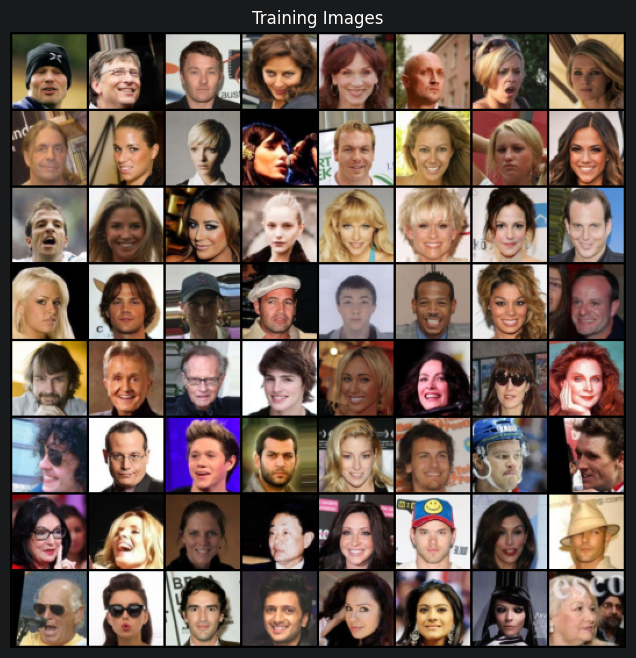

In [13]:
# Dataset and dataloader
# Source: https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

dataset = dset.ImageFolder(
    root=dataroot,
    transform=transforms.Compose(
        [
            transforms.Resize(IMAGE_SIZE),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    ),
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=WORKERS,
)

# Decide which device to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and NGPU > 0) else "cpu")

# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),
        (1, 2, 0),
    )
)
plt.show()

In [16]:
import torch.nn as nn


def weights_init(m: nn.Module) -> None:
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## Generator layers explained

### ConvTranspose2d — grows the image

```
torch.nn.ConvTranspose2d(
    in_channels=100,    # how many input feature maps
    out_channels=512,   # how many output feature maps
    kernel_size=4,      # 4×4 sliding window
    stride=1,           # stride 1 → output grows slowly (1×1 → 4×4)
    stride=2,           # stride 2 → output doubles (4×4 → 8×8 → ... → 64×64)
    padding=0,          # stride 1 layers use padding=0
    padding=1,          # stride 2 layers use padding=1
    bias=False,         # no extra bias — BatchNorm handles it
)
```

ConvTranspose2d is the generator's engine: it takes a small input and "paints" a larger output
using learned patterns. Each layer doubles the spatial size while halving the channels.

| Layer | Shape out | Channels |
|---|---|---|
| Input z | 1×1 | 100 |
| ConvTranspose2d (stride=1) | 4×4 | 512 |
| ConvTranspose2d (stride=2) | 8×8 | 256 |
| ConvTranspose2d (stride=2) | 16×16 | 128 |
| ConvTranspose2d (stride=2) | 32×32 | 64 |
| ConvTranspose2d (stride=2) | 64×64 | 3 (RGB) |

### BatchNorm2d — the stabilizer

During training, numbers flowing through the network can explode or vanish, stopping learning.
BatchNorm looks at the current batch, computes mean and standard deviation for each channel,
and rescales values to stay in a healthy range. It acts like a thermostat for activations.

The `num_features` argument must match the `out_channels` of the layer right before it.
That's why you see `num_features=NGF*8` right after `out_channels=NGF*8`.

### Why `bias=False` on every ConvTranspose2d

BatchNorm has its own learned bias internally. If the convolution also has a bias,
they fight each other. Removing the conv's bias avoids the conflict and saves memory.

### ReLU and Tanh — the activation functions

- **ReLU**: clips negative values to 0. Keeps the signal clean. Used after every BatchNorm.
- **Tanh**: squashes outputs to [-1, 1]. Used only on the final layer, because images are
  normalized to [-1, 1] by the dataset transform — they must match.

### State size comments

Comments like `# state size: (NGF*4) x 8 x 8` mean:
```
channels=NGF*4=256, height=8, width=8   (batch dimension omitted)
```
The full tensor shape is `(BATCH_SIZE, 256, 8, 8)`.

In [15]:
class Generator(torch.nn.Module):
    def __init__(self, ngpu: int) -> None:
        super().__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(
                in_channels=NUMBER_Z_DIMENSIONS,
                out_channels=NUMBER_GENERATOR_FEATURES * 8,
                kernel_size=4,
                stride=1,
                padding=0,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=NUMBER_GENERATOR_FEATURES * 8),
            nn.ReLU(inplace=True),
            # state size: (NUMBER_GENERATOR_FEATURES*8) x 4 x 4
            nn.ConvTranspose2d(
                in_channels=NUMBER_GENERATOR_FEATURES * 8,
                out_channels=NUMBER_GENERATOR_FEATURES * 4,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=NUMBER_GENERATOR_FEATURES * 4),
            nn.ReLU(inplace=True),
            # state size: (NUMBER_GENERATOR_FEATURES*4) x 8 x 8
            nn.ConvTranspose2d(
                in_channels=NUMBER_GENERATOR_FEATURES * 4,
                out_channels=NUMBER_GENERATOR_FEATURES * 2,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=NUMBER_GENERATOR_FEATURES * 2),
            nn.ReLU(inplace=True),
            # state size: (NUMBER_GENERATOR_FEATURES*2) x 16 x 16
            nn.ConvTranspose2d(
                in_channels=NUMBER_GENERATOR_FEATURES * 2,
                out_channels=NUMBER_GENERATOR_FEATURES,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=NUMBER_GENERATOR_FEATURES),
            nn.ReLU(inplace=True),
            # state size: (NUMBER_GENERATOR_FEATURES) x 32 x 32
            nn.ConvTranspose2d(
                in_channels=NUMBER_GENERATOR_FEATURES,
                out_channels=NUMBER_CHANNELS,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.Tanh(),
            # state size: (nc) x 64 x 64
        )

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        return self.main(input)

## Conv2d vs ConvTranspose2d — shrink vs grow

Both take the same arguments (kernel_size, stride, padding), but do opposite things:

| | Conv2d (discriminator) | ConvTranspose2d (generator) |
|---|---|---|
| Direction | Shrinks: 64×64 → 1×1 | Grows: 1×1 → 64×64 |
| Stride 2 | Output is half the input size | Output is double the input size |
| Mental model | Zooming out, summarizing | Painting details between pixels |
| Can it grow? | No — max preserves size with stride=1 | Yes — its purpose |

Conv2d with stride=1 and proper padding can preserve size (8×8 → 8×8), but it can never increase it.
Growing requires either ConvTranspose2d or Upsample + Conv2d.

### LeakyReLU vs ReLU — the discriminator's choice

| | ReLU | LeakyReLU |
|---|---|---|
| Negative inputs | 0 (dead neuron) | 0.2 × input (tiny negative signal) |
| Used in | Generator | Discriminator |
| Why | Simple, clean signal | Prevents dead gradients in adversarial training |

A regular ReLU clips negatives to zero — if a neuron goes negative, it stops learning forever.
LeakyReLU lets 20% of the negative signal through, so neurons can recover later.